## Train simple BERT model

### Use SLALOM Explanations to explain samples from the different datasets.

In [1]:
%load_ext autoreload
%autoreload 2

In [21]:
from src.dataset import load_gtc, load_ptsd

## Setup dataset

In [6]:
from src.classification_models import BERTmodel, RoBERTamodel, RoBERTaPretrainedmodel

In [7]:
model = RoBERTaPretrainedmodel(device="cpu")
#tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased', use_fast=True)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Step 1: Load model

In [8]:
model.load("logs_GTC/models/RoBERTaPretrainedmodel_n_layers-12_lr-2.043706578410144e-06_GTC_r0.pt") ## Model on GTC

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
#model.load("logs/models/BERTmodel_n_layers-5_n_heads-8_d_hidden-1536_lr-2.3153818430467197e-05_PTSD_r0.pt") ## Model on PTSD

In [26]:
## Test if the model is correctly loaded
# read data
genocide_ds = load_gtc("Dataset_GTC-V2.csv")
#>res = model.predict_proba(genocide_ds["test"]["text"])

In [11]:
from src.compute_metrics import accuracy_score

In [ ]:
print(accuracy_score(res, genocide_ds["test"]["label"]))

## Step 2: Find relevant tokens

To compute SLALOM scores for every token in the vocabulary we initially need to identify unique tokens in the vocabulary of the respective datasets.

Example: GTC

In [27]:
from transformers import AutoTokenizer
tokenizer = model.tokenizer

In [28]:
tokens = tokenizer(genocide_ds["test"]["text"], padding=True)

In [29]:
import torch
used_tokens_gtc = torch.unique(torch.tensor(tokens["input_ids"]))

In [30]:
len(used_tokens_gtc)

8070

Example PTSD

In [17]:
ptsd_ds = load_ptsd("labeled_post_v2s.csv")

NameError: name 'load_ptsd' is not defined

In [18]:
tokens = tokenizer(ptsd_ds["test"]["text"], padding=True)

NameError: name 'ptsd_ds' is not defined

In [19]:
import torch
used_tokens_ptsd = torch.unique(torch.tensor(tokens["input_ids"]))

NameError: name 'tokens' is not defined

In [20]:
len(used_tokens_ptsd)

NameError: name 'used_tokens_ptsd' is not defined

## Overall tokens

In [ ]:
all_datasets_unique = torch.unique(torch.cat((used_tokens_gtc, used_tokens_ptsd), dim=0))

In [31]:
len(all_datasets_unique)

8746

## Compute Global SLALOM Explanations for both datasets

``offline_ds_size``describes how many samples are used to fit explanations. -> at least 10x number of tokens to be explained

In [32]:
from src.slalom import fit_sgd_rand, MyLittleSLALOM

In [36]:
use_device="cpu"
example_slalom_model = MyLittleSLALOM(used_tokens_gtc, device=use_device).to(use_device)
_, _, mymodel = fit_sgd_rand(example_slalom_model, model.model.model, used_tokens_gtc, num_eps=30, lr=1e-2, subsize=250, batch_size=32, seq_len=2, use_cls=True, fixed_len=True, offline_ds_size=100000)

26.210060678998794
26.084824079194348
25.959994480036606
25.832887678841573
25.70301375519407
25.570073585294537
25.433833420394947
25.29410606726971
25.150751305326494
25.003673398223185
24.852833007604083
24.698238494599742
24.53995898997384
24.378111268000865
24.212861584986754
24.04441895879643
23.87303054611629
23.698970140207358
23.522533940968106
23.344029920440274
23.16377229928909
22.982070515991037
22.79922877529954
22.615535655517952
22.431263391518684
22.246664195089828
22.061969097296124
21.877386459902528
21.693101451449003
21.50927858199336


In [24]:
my_imp = mymodel.get_importances()
my_vals = mymodel.get_values()

## 4. Plot all SLALOM scores

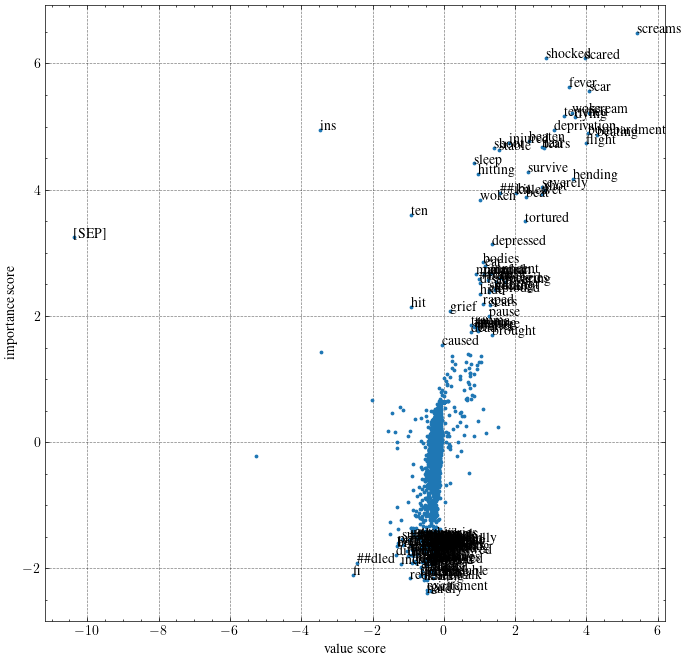

In [27]:
# First scatter plot
tok_list = []
ybounds = {"PTSD": [1.5,2.25], "GTC": [3.5,6.5]}
xbounds = {"PTSD": [0,3], "GTC": [0,5]}
tokens = {"PTSD": used_tokens_ptsd, "GTC": used_tokens_gtc}
dset = "PTSD"
import matplotlib.pyplot as plt
plt.scatter(my_vals.cpu(), my_imp.cpu(), 3, c="tab:blue")
for k in range(len(my_vals)): #imp, vals in zip(used_tokens_ptsd, my_imp, my_vals):
    if torch.abs(my_imp[k]) > ybounds[dset][0]:
        tok_str = tokenizer.convert_ids_to_tokens(tokens[dset][k].item())
        tok_str = tok_str.replace("Ġ", "") # For GPT model
        tok_list.append(tok_str)
        plt.annotate(tok_str.replace("##", r"\#\#"), xy=(my_vals[k].item(), my_imp[k].item()), fontsize=10)
plt.xlabel("value score")
plt.ylabel("importance score")
#plt.ylim(ybounds[dset])
#plt.xlim(xbounds[dset])
plt.gcf().set_size_inches(8,8)
#plt.gcf().savefig(f"figures/SLALOM_{dset}.pdf")
#plt.plot([-2, 2], [-2,2], "--k")

## 5 Create a nice plot of the relevant words.

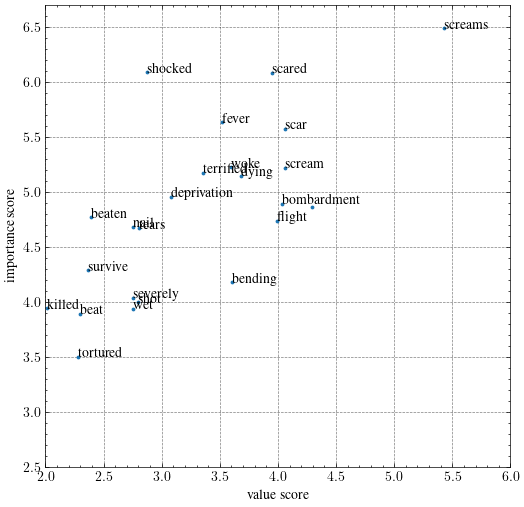

In [30]:
import matplotlib.pyplot as plt
plt.style.use('figures/matplot.mplstyle')
tok_list = []
ybounds = {"PTSD": [2.5,6.7], "GTC": [3.5,6.5]}
xbounds = {"PTSD": [2,6.0], "GTC": [0,5]}
tokens = {"PTSD": used_tokens_ptsd, "GTC": used_tokens_gtc}
dset = "PTSD"
import matplotlib.pyplot as plt
plt.scatter(my_vals.cpu(), my_imp.cpu(), 3, c="tab:blue")
for k in range(len(my_vals)): #imp, vals in zip(used_tokens_ptsd, my_imp, my_vals):
    if torch.abs(my_imp[k]) > ybounds[dset][0]:
        tok_str = tokenizer.convert_ids_to_tokens(tokens[dset][k].item())
        tok_str = tok_str.replace("Ġ", "") # For GPT model
        tok_list.append(tok_str)
        ## Filter:
        if tok_str not in ["spoon", "raped", "beating"]:
            plt.annotate(tok_str.replace("##", r"\#\#"), xy=(my_vals[k].item(), my_imp[k].item()), fontsize=10)
plt.xlabel("value score")
plt.ylabel("importance score")
plt.ylim(ybounds[dset])
plt.xlim(xbounds[dset])
plt.gcf().set_size_inches(6,6)
plt.gcf().savefig(f"figures/SLALOM_{dset}.pdf")

In [48]:
len(my_vals)

4404